In [2]:
!pip install --upgrade sidechainnet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 39.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 93.0 MB/s eta 0:00:00
Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
!pip install numpy==1.26
!pip install openmm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 72.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.5
    Uninstalling numpy-1.23.5:
      Successfully uninstalled numpy-1.23.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
prody 2.4.1 requires numpy<1.24,>=1.10, but you have numpy 1.26.0 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 24.1 MB/s eta 0:00:00


In [4]:
import numpy as np
import sidechainnet as scn
from sidechainnet.utils.sequence import ProteinVocabulary
from sidechainnet.structure.build_info import NUM_COORDS_PER_RES

INFO:.prody:ProDy is configured: verbosity='none'
INFO:.prody:ProDy is configured: auto_secondary=False


In [5]:
def load_and_thin_casp12_30(thin_factor=10):
    """Load CASP 12-30 data and thin it by selecting every nth protein."""
    # Load SidechainNet data (this will download if not already present)
    data = scn.load(casp_version="12", thinning=30, with_pytorch="dataloaders")  # Initial thinning to reduce memory

    # Get the training data
    train_data = data["train"]

    return train_data

In [6]:


def dataloader_to_numpy(dataloader, max_length=200):
    """
    Convert SidechainNet dataloader to numpy arrays.
    Handles variable-length sequences by padding to max_length.
    """
    vocab = ProteinVocabulary()

    # Initialize lists to store data
    sequences = []
    angles = []
    coordinates = []
    masks = []

    for batches in dataloader:
        batch_seq, batch_angles, batch_coords, batch_mask = batches.seqs, batches.angles, batches.coords, batches.masks
        # Convert to numpy and process each item in the batch
        for i in range(len(batch_seq)):
            # Sequence (convert from indices to letters)
            #seq_indices = batch_seq[i].numpy()
            seq = batch_seq[i].numpy()#"".join([vocab.int2char(aa) for aa in seq_indices])

            # Angles (torsion angles)
            ang = batch_angles[i].numpy()

            # Coordinates (3D positions)
            coord = batch_coords[i].numpy()

            # Mask (which residues are valid)
            mask = batch_mask[i].numpy()

            # Pad sequences to max_length if needed
            if len(seq) < max_length:
                pad_length = max_length - len(seq)
                seq = np.pad(seq, ((0, pad_length), (0, 0)), 'constant', constant_values=0)
                ang = np.pad(ang, ((0, pad_length), (0, 0)), 'constant', constant_values=0)
                #oord = np.pad(coord, ((0, pad_length * NUM_COORDS_PER_RES), (0, 0)), 'constant', constant_values=0)
                #mask = np.pad(mask, (0, pad_length), 'constant', constant_values=0)
            elif len(seq) > max_length:
                # Truncate if too long
                seq = seq[:max_length]
                ang = ang[:max_length]
                #coord = coord[:max_length * NUM_COORDS_PER_RES]
                #mask = mask[:max_length]

            print(str(seq.shape)+" "+str(ang.shape))
            sequences.append(seq.ravel())
            angles.append(ang)
            #coordinates.append(coord)
            #masks.append(mask)

    # Convert lists to numpy arrays
    sequences = np.array(sequences)
    angles = np.array(angles)
    #coordinates = np.array(coordinates)
    #masks = np.array(masks)

    return sequences, angles, coordinates, masks


In [7]:
print("Loading and thinning CASP 12-30 data...")
thinned_data = load_and_thin_casp12_30(thin_factor=20)

Loading and thinning CASP 12-30 data...
SidechainNet was loaded from ./sidechainnet_data/sidechainnet_casp12_30.pkl.


In [8]:
sequences, angles, coordinates, masks = dataloader_to_numpy(thinned_data)
# Print some info
print(f"Number of proteins: {len(sequences)}")
print(f"Sequence shape: {sequences.shape}")
print(f"Angles shape: {angles.shape}")
#print(f"Coordinates shape: {coordinates.shape}")
#print(f"Masks shape: {masks.shape}")

Streaming output truncated to the last 5000 lines.
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20) (200, 12)
(200, 20)

In [9]:
sequences = np.load('/content/drive/MyDrive/seq.npy')
angles = np.load('/content/drive/MyDrive/angles.npy')
print(sequences.shape)
print(angles.shape)

(3000, 4000)
(3000, 200, 12)


In [10]:
from sklearn.cluster import SpectralClustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
clustering = AgglomerativeClustering(n_clusters=4)
clustering.fit(sequences)
families = clustering.labels_
print(np.unique(families, return_counts=True))
np.save("/content/drive/MyDrive/families",families)

(array([0, 1, 2, 3]), array([1176,  329,  731,  764]))


In [ ]:
sequences = sequences[0:3000]
angles = angles[0:3000]
print(f"Sequence shape: {sequences.shape}")
print(f"Angles shape: {angles.shape}")

Sequence shape: (3000, 4000)
Angles shape: (3000, 200, 12)


In [ ]:
np.save('/content/drive/MyDrive/seq',sequences)
np.save('/content/drive/MyDrive/angles', angles)

ValueError: 'c' argument has 4000 elements, which is inconsistent with 'x' and 'y' with size 200.

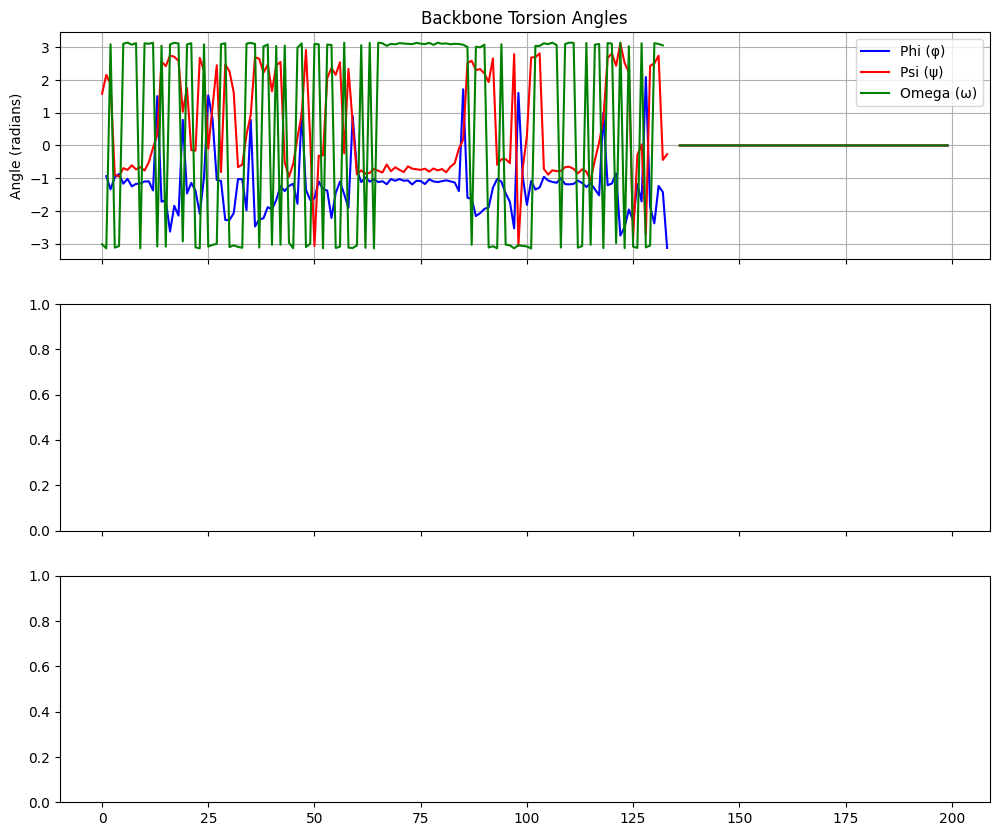

In [ ]:
import matplotlib.pyplot as plt

data = angles[0]
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
# Backbone angles (phi, psi, omega)
ax1.plot(data[:, 0], 'b-', label='Phi (φ)')
ax1.plot(data[:, 1], 'r-', label='Psi (ψ)')
ax1.plot(data[:, 2], 'g-', label='Omega (ω)')
ax1.set_ylabel('Angle (radians)')
ax1.set_title('Backbone Torsion Angles')
ax1.legend()
ax1.grid(True)

ax2.scatter(data[:, 0], data[:, 1], c=range(len(sequences[0])), cmap='viridis')
ax2.set_xlabel('Phi (φ)')
ax2.set_ylabel('Psi (ψ)')
ax2.set_title('Ramachandran Plot')
ax2.grid(True)

ax3.set_xlabel('Residue Index')
ax3.set_ylabel('Angle (radians)')
ax3.set_title('Sidechain Torsion Angles')
ax3.legend()
ax3.grid(True)
# Add sequence information
seq_str = f"Sequence (len={len(sequences[0])}): {sequences[0]}"
fig.suptitle("aa")
plt.tight_layout()
plt.show()

In [ ]:
import py3Dmol
from sidechainnet.structure.StructureBuilder import StructureBuilder

In [ ]:
def reconstruct_from_angles(angles, sequence):
    """Reconstruct 3D coordinates from torsion angles using SidechainNet's builder"""
    builder = StructureBuilder(sequence, angles)
    builder.build()
    return builder.get_coords()

In [ ]:
coords = reconstruct_from_angles(angles[0], sequences[0])
print(coords)

ValueError: Building atomic coordinates from angles is not supported for structures with missing residues. Missing residues = [134, 135]. Protein structures with missing residues are only supported if built directly from coordinates (also supported by StructureBuilder).